In [1]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import matplotlib.colors as mcolors

In [2]:
# === Load the Drug–ADR matrix ===
drug_adr_mat = np.loadtxt("drug_se_mat.txt")

In [3]:
# Load mapping files
with open("id2adr.json", "r") as f:
    id2adr = json.load(f)

with open("decoded_adrs.json", "r") as f:
    decoded_adrs = json.load(f)

In [4]:
# ========== PREPARE DATA ==========
# Sum over rows (each ADR: number of drugs associated)
adr_freq = drug_adr_mat.sum(axis=0)
adr_freq = np.array(adr_freq).flatten()

In [5]:
# Map ADR IDs to names
adr_names = [decoded_adrs.get(id2adr[str(i)], f"ADR_{i}") for i in range(len(adr_freq))]

In [6]:
# Create DataFrame
df_adr = pd.DataFrame({
    "ADR": adr_names,
    "Count": adr_freq
}).sort_values("Count", ascending=False).reset_index(drop=True)

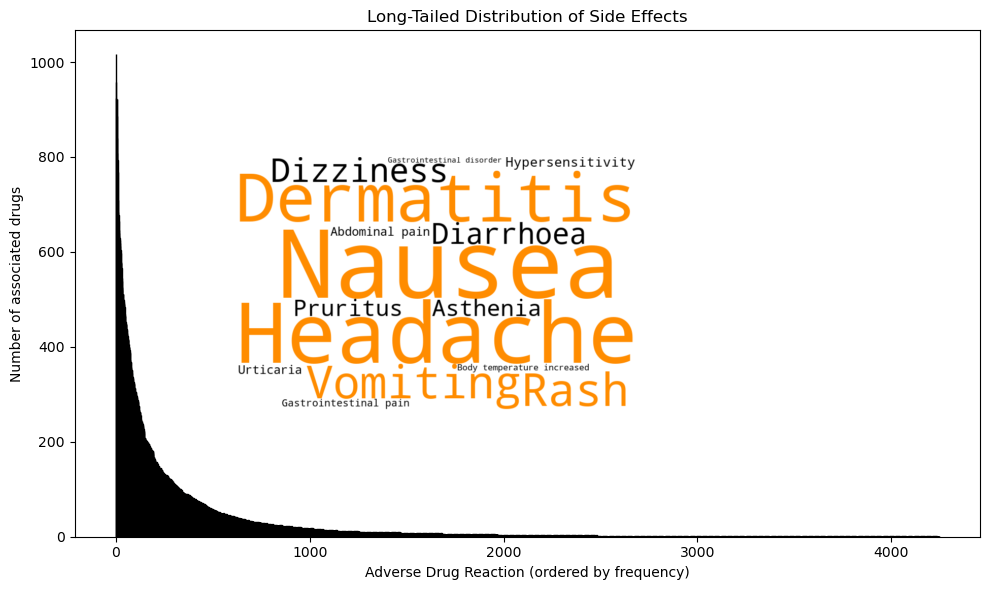

In [7]:
# ========== PLOT LONG-TAIL DISTRIBUTION ==========
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(range(len(df_adr)), df_adr["Count"], color="skyblue", edgecolor="black")
ax.set_xlabel("Adverse Drug Reaction (ordered by frequency)")
ax.set_ylabel("Number of associated drugs")
ax.set_title("Long-Tailed Distribution of Side Effects")

# ========== INSET: WORD CLOUD ==========
# Top 15 ADRs
top15 = df_adr.head(15)

# Create word frequency dict
word_freq = dict(zip(top15["ADR"], top15["Count"]))

# Define colors (orange for top 5)
def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    top5_words = set(top15["ADR"].iloc[:5])
    return "darkorange" if word in top5_words else "black"

# Generate word cloud
wc = WordCloud(
    width=800, height=500,
    background_color="white",
    color_func=color_func,
    prefer_horizontal=1.0
).generate_from_frequencies(word_freq)

# Add inset axis
inset_ax = ax.inset_axes([0.15, 0.25, 0.5, 0.5])
inset_ax.imshow(wc, interpolation="bilinear")
inset_ax.axis("off")

plt.tight_layout()
plt.savefig("ADR_LongTail_WordCloud.png", dpi=300, bbox_inches="tight")
plt.show()

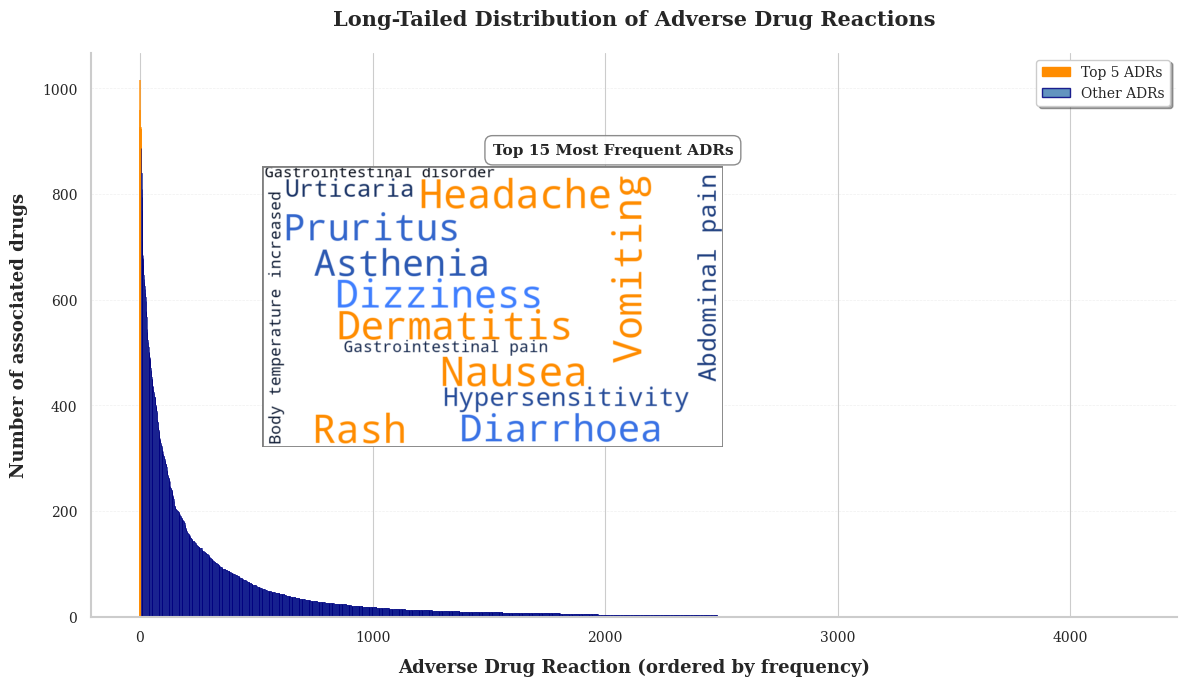

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

# ========== PLOT LONG-TAIL DISTRIBUTION ==========
fig, ax = plt.subplots(figsize=(12, 7))

# Create gradient color effect
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(df_adr)))

# Main bar plot
bars = ax.bar(range(len(df_adr)), df_adr["Count"], 
              color=colors, edgecolor='navy', linewidth=0.5, alpha=0.85)

# Highlight top 5 with different color
for i in range(min(5, len(df_adr))):
    bars[i].set_color('#FF8C00')
    bars[i].set_edgecolor('darkorange')
    bars[i].set_linewidth(1.2)

# Styling
ax.set_xlabel("Adverse Drug Reaction (ordered by frequency)", 
              fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel("Number of associated drugs", 
              fontsize=13, fontweight='bold', labelpad=10)
ax.set_title("Long-Tailed Distribution of Adverse Drug Reactions", 
             fontsize=15, fontweight='bold', pad=20)

# Grid styling
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5, axis='y')
ax.set_axisbelow(True)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# Tick styling
ax.tick_params(axis='both', which='major', labelsize=10, length=6, width=1.5)

# ========== INSET: WORD CLOUD ==========
# Top 15 ADRs
top15 = df_adr.head(15)

# Create word frequency dict
word_freq = dict(zip(top15["ADR"], top15["Count"]))

# Define colors with gradient (orange for top 5, blue gradient for rest)
def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    top5_words = set(top15["ADR"].iloc[:5])
    if word in top5_words:
        return "darkorange"
    else:
        # Blue gradient for non-top5
        idx = list(top15["ADR"]).index(word)
        intensity = int(255 * (1 - (idx - 5) / 10))  # Darker to lighter
        return f'#{intensity//4:02x}{intensity//2:02x}{intensity:02x}'

# Generate word cloud with better aesthetics
wc = WordCloud(
    width=900, height=550,
    background_color="white",
    color_func=color_func,
    prefer_horizontal=0.8,
    relative_scaling=0.5,
    min_font_size=10,
    max_font_size=80,
    font_path=None,  # Use default font
    contour_width=1,
    contour_color='lightgray'
).generate_from_frequencies(word_freq)

# Add inset axis with frame
inset_ax = ax.inset_axes([0.12, 0.30, 0.50, 0.50])
inset_ax.imshow(wc, interpolation="bilinear")
inset_ax.axis("off")

# Add frame around word cloud
frame = plt.Rectangle((0, 0), 1, 1, 
                      transform=inset_ax.transAxes,
                      fill=False, edgecolor='gray', 
                      linewidth=2, linestyle='-')
inset_ax.add_patch(frame)

# Add label to inset
ax.text(0.37, 0.82, 'Top 15 Most Frequent ADRs', 
        transform=ax.transAxes,
        fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', 
                 facecolor='white', 
                 edgecolor='gray',
                 alpha=0.9))

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF8C00', edgecolor='darkorange', label='Top 5 ADRs'),
    Patch(facecolor='#4682B4', edgecolor='navy', label='Other ADRs', alpha=0.85)
]
ax.legend(handles=legend_elements, loc='upper right', 
         frameon=True, fancybox=True, shadow=True, fontsize=10)

plt.tight_layout()
plt.savefig("ADR_LongTail_WordCloud.png", dpi=300, bbox_inches="tight")
plt.show()

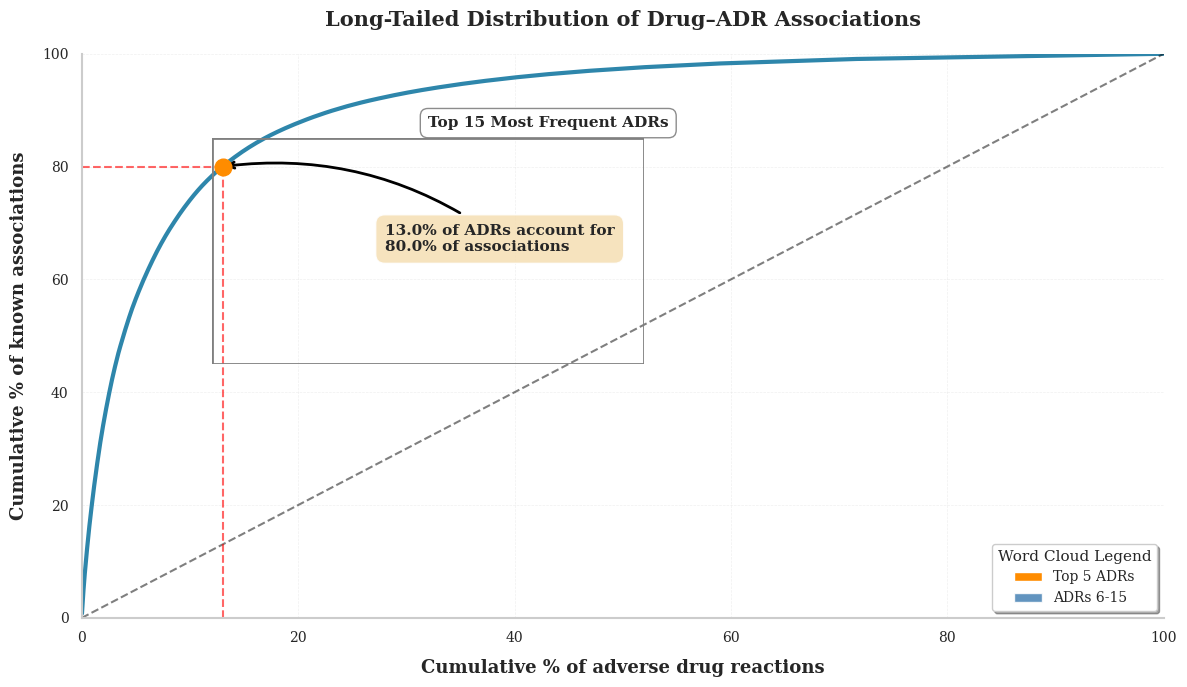


13.0% of side effects are responsible for 80.0% of the associations


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

# ========== PREPARE DATA FOR LORENZ CURVE ==========
# Sort ADRs by count (descending)
df_sorted = df_adr.sort_values("Count", ascending=False).reset_index(drop=True)

# Calculate cumulative percentages
total_associations = df_sorted["Count"].sum()
cumulative_associations = df_sorted["Count"].cumsum()
cumulative_pct_associations = (cumulative_associations / total_associations) * 100

total_adrs = len(df_sorted)
cumulative_pct_adrs = np.arange(1, total_adrs + 1) / total_adrs * 100

# Find the point where ~30% of ADRs account for ~80% of associations
idx_80 = np.where(cumulative_pct_associations >= 80)[0]
if len(idx_80) > 0:
    idx_80 = idx_80[0]
    pct_adrs_at_80 = cumulative_pct_adrs[idx_80]
    pct_assoc_at_80 = cumulative_pct_associations[idx_80]
else:
    idx_80 = None

# ========== PLOT LORENZ CURVE ==========
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the Lorenz curve
line = ax.plot(cumulative_pct_adrs, cumulative_pct_associations, 
               color='#2E86AB', linewidth=3, label='Actual distribution')

# Plot diagonal (perfect equality)
ax.plot([0, 100], [0, 100], 'k--', linewidth=1.5, alpha=0.5, label='Perfect equality')

# Highlight the 80% point if found
if idx_80 is not None:
    ax.plot(pct_adrs_at_80, pct_assoc_at_80, 'o', 
            color='darkorange', markersize=12, zorder=5)
    
    # Add dashed lines to axes
    ax.plot([pct_adrs_at_80, pct_adrs_at_80], [0, pct_assoc_at_80], 
            'r--', linewidth=1.5, alpha=0.6)
    ax.plot([0, pct_adrs_at_80], [pct_assoc_at_80, pct_assoc_at_80], 
            'r--', linewidth=1.5, alpha=0.6)
    
    # Add annotation
    ax.annotate(f'{pct_adrs_at_80:.1f}% of ADRs account for\n{pct_assoc_at_80:.1f}% of associations', 
                xy=(pct_adrs_at_80, pct_assoc_at_80), 
                xytext=(pct_adrs_at_80 + 15, pct_assoc_at_80 - 15),
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.6', facecolor='wheat', alpha=0.85),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2', 
                              color='black', lw=2))

# Styling
ax.set_xlabel("Cumulative % of adverse drug reactions", 
              fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel("Cumulative % of known associations", 
              fontsize=13, fontweight='bold', labelpad=10)
ax.set_title("Long-Tailed Distribution of Drug–ADR Associations", 
             fontsize=15, fontweight='bold', pad=20)

# Set limits
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

# Grid styling
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# Tick styling
ax.tick_params(axis='both', which='major', labelsize=10, length=6, width=1.5)

# ========== INSET: WORD CLOUD ==========
# Top 15 ADRs
top15 = df_sorted.head(15)

# Create word frequency dict
word_freq = dict(zip(top15["ADR"], top15["Count"]))

# Define colors with gradient (orange for top 5, blue gradient for rest)
def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    top5_words = set(top15["ADR"].iloc[:5])
    if word in top5_words:
        return "darkorange"
    else:
        # Blue gradient for non-top5
        idx = list(top15["ADR"]).index(word)
        intensity = int(255 * (1 - (idx - 5) / 10))
        return f'#{intensity//4:02x}{intensity//2:02x}{intensity:02x}'

# Generate word cloud
wc = WordCloud(
    width=900, height=550,
    background_color="white",
    color_func=color_func,
    prefer_horizontal=0.8,
    relative_scaling=0.5,
    min_font_size=10,
    max_font_size=80,
    contour_width=1,
    contour_color='lightgray'
).generate_from_frequencies(word_freq)

# Add inset axis
inset_ax = ax.inset_axes([0.12, 0.45, 0.40, 0.40])
inset_ax.axis("off")

# Add frame around word cloud
frame = plt.Rectangle((0, 0), 1, 1, 
                      transform=inset_ax.transAxes,
                      fill=False, edgecolor='gray', 
                      linewidth=2, linestyle='-')
inset_ax.add_patch(frame)

# Add label to inset
ax.text(0.32, 0.87, 'Top 15 Most Frequent ADRs', 
        transform=ax.transAxes,
        fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', 
                 facecolor='white', 
                 edgecolor='gray',
                 alpha=0.9))

# Add legend for word cloud colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='darkorange', label='Top 5 ADRs'),
    Patch(facecolor='#4682B4', label='ADRs 6-15', alpha=0.85)
]
ax.legend(handles=legend_elements, loc='lower right', 
         frameon=True, fancybox=True, shadow=True, fontsize=10,
         title='Word Cloud Legend')

plt.tight_layout()
plt.savefig("ADR_LongTail_Lorenz.png", dpi=300, bbox_inches="tight")
plt.show()

# ========== PRINT STATISTICS ==========
if idx_80 is not None:
    print(f"\n{pct_adrs_at_80:.1f}% of side effects are responsible for {pct_assoc_at_80:.1f}% of the associations")

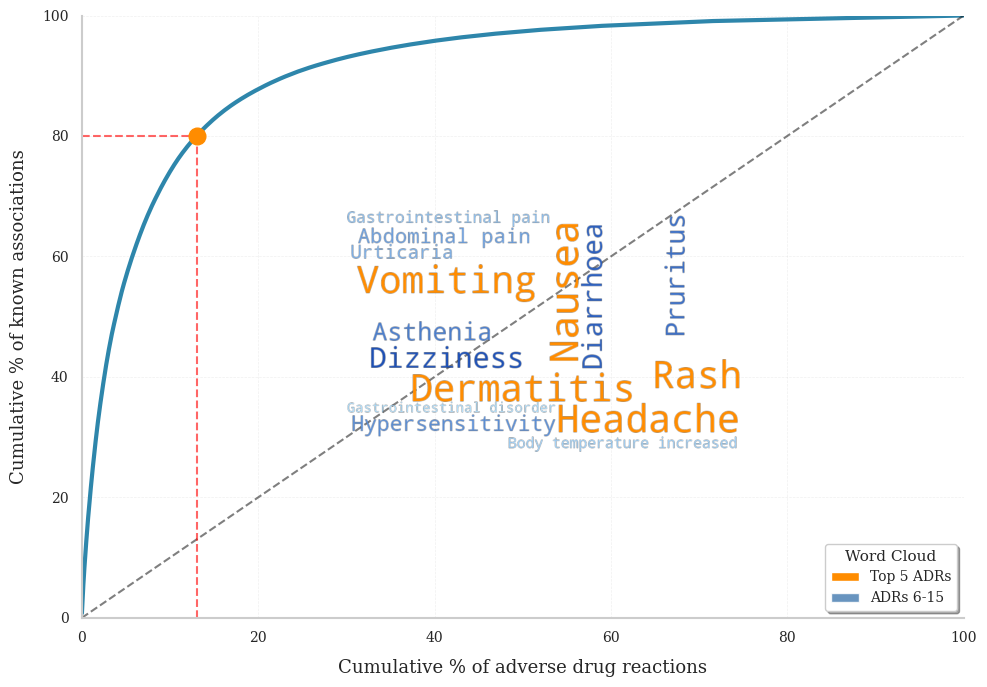


13.0% of side effects are responsible for 80.0% of the associations


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

# ========== PREPARE DATA FOR LORENZ CURVE ==========
# Sort ADRs by count (descending)
df_sorted = df_adr.sort_values("Count", ascending=False).reset_index(drop=True)

# Calculate cumulative percentages
total_associations = df_sorted["Count"].sum()
cumulative_associations = df_sorted["Count"].cumsum()
cumulative_pct_associations = (cumulative_associations / total_associations) * 100

total_adrs = len(df_sorted)
cumulative_pct_adrs = np.arange(1, total_adrs + 1) / total_adrs * 100

# Find the point where ~30% of ADRs account for ~80% of associations
idx_80 = np.where(cumulative_pct_associations >= 80)[0]
if len(idx_80) > 0:
    idx_80 = idx_80[0]
    pct_adrs_at_80 = cumulative_pct_adrs[idx_80]
    pct_assoc_at_80 = cumulative_pct_associations[idx_80]
else:
    idx_80 = None

# ========== PLOT LORENZ CURVE ==========
fig, ax = plt.subplots(figsize=(10, 7))

# Plot the Lorenz curve
line = ax.plot(cumulative_pct_adrs, cumulative_pct_associations, 
               color='#2E86AB', linewidth=3, label='Actual distribution')

# Plot diagonal (perfect equality)
ax.plot([0, 100], [0, 100], 'k--', linewidth=1.5, alpha=0.5, label='Perfect equality')

# Highlight the 80% point if found
if idx_80 is not None:
    ax.plot(pct_adrs_at_80, pct_assoc_at_80, 'o', 
            color='darkorange', markersize=12, zorder=5)
    
    # Add dashed lines to axes
    ax.plot([pct_adrs_at_80, pct_adrs_at_80], [0, pct_assoc_at_80], 
            'r--', linewidth=1.5, alpha=0.6)
    ax.plot([0, pct_adrs_at_80], [pct_assoc_at_80, pct_assoc_at_80], 
            'r--', linewidth=1.5, alpha=0.6)

# Styling
ax.set_xlabel("Cumulative % of adverse drug reactions", 
              fontsize=13, labelpad=10)
ax.set_ylabel("Cumulative % of known associations", 
              fontsize=13, labelpad=10)

# Set limits
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

# Grid styling
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# Tick styling
ax.tick_params(axis='both', which='major', labelsize=10, length=6, width=1.5)

# ========== INSET: WORD CLOUD ==========
# Top 15 ADRs
top15 = df_sorted.head(15)

# Create word frequency dict with enhanced weights for better size variation
word_freq = {}
max_count = top15["Count"].iloc[0]
for idx, row in top15.iterrows():
    # Exponential scaling for better size differentiation
    if idx < 5:  # Top 5 keep original weight
        word_freq[row["ADR"]] = row["Count"]
    else:  # Enhance differences for 6-15
        # Scale between 20% and 60% of max for better visual separation
        scaled_weight = max_count * (0.2 + 0.4 * (15 - (idx + 1)) / 10)
        word_freq[row["ADR"]] = scaled_weight

# Define colors with better gradient
def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    top5_words = set(top15["ADR"].iloc[:5])
    if word in top5_words:
        return "darkorange"
    else:
        # More pronounced blue gradient for non-top5
        idx = list(top15["ADR"]).index(word)
        # Scale from dark blue to light blue
        ratio = (idx - 5) / 10  # 0 to 1 for positions 6-15
        r = int(30 + ratio * 150)   # 30 to 180
        g = int(80 + ratio * 150)   # 80 to 230
        b = int(180 + ratio * 75)   # 180 to 255
        return f'#{r:02x}{g:02x}{b:02x}'

# Generate word cloud with better size variation
wc = WordCloud(
    width=900, height=550,
    background_color=None,  # Transparent background
    mode='RGBA',
    color_func=color_func,
    prefer_horizontal=0.75,
    relative_scaling=0.6,  # Increased for better size variation
    min_font_size=12,
    max_font_size=90,
    contour_width=0
).generate_from_frequencies(word_freq)

# Add inset axis - moved more to the right and down
inset_ax = ax.inset_axes([0.30, 0.25, 0.45, 0.45])
inset_ax.imshow(wc, interpolation="bilinear")
inset_ax.axis("off")

# Add legend for word cloud colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='darkorange', label='Top 5 ADRs'),
    Patch(facecolor='#4E82B4', label='ADRs 6-15', alpha=0.85)
]
ax.legend(handles=legend_elements, loc='lower right', 
         frameon=True, fancybox=True, shadow=True, fontsize=10,
         title='Word Cloud')

plt.tight_layout()
plt.savefig("ADR_LongTail_Lorenz.pdf", dpi=300, bbox_inches="tight", facecolor='white')
plt.show()

# ========== PRINT STATISTICS ==========
if idx_80 is not None:
    print(f"\n{pct_adrs_at_80:.1f}% of side effects are responsible for {pct_assoc_at_80:.1f}% of the associations")

In [11]:
# Print summary
print(f"Mean ADRs per drug: {drug_adr_mat.sum(axis=1).mean():.2f}")
print(f"Median ADRs per drug: {np.median(drug_adr_mat.sum(axis=1)):.2f}")
print(f"Max ADRs per drug: {drug_adr_mat.sum(axis=1).max():.0f}")
print(f"Drugs with zero ADRs: {(drug_adr_mat.sum(axis=1) == 0).sum()}")

Mean ADRs per drug: 111.48
Median ADRs per drug: 79.00
Max ADRs per drug: 742
Drugs with zero ADRs: 0
